# EDA for Personal Project

In [1]:
import os
import glob
import json
import pandas as pd
import numpy as np
from bs4 import BeautifulSoup
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.feature_extraction.text import CountVectorizer
from wordcloud import WordCloud
import warnings
from sklearn.preprocessing import MultiLabelBinarizer
warnings.filterwarnings('ignore')

## Pre-processing and standardizing the data and plots

This process loads spell JSON files, extracts useful fields, cleans descriptions, and creates analysis columns.

In [2]:
data_path = 'spellsdata/**/*.json'
parsed_spells = []

example_files = [
    filepath for filepath in glob.glob(data_path, recursive=True)
    if '_folders.json' not in filepath
]
if example_files:
    with open(example_files[0], 'r', encoding='utf-8') as f:
        example_spell = json.load(f)
    print('Example of a typical spell JSON file:')
    print(json.dumps(example_spell, indent=2, ensure_ascii=False)[:3000])
else:
    print('No spell JSON files found. Check the data_path.')

for filepath in glob.glob(data_path, recursive=True):
    if '_folders.json' in filepath:
        continue
    try:
        with open(filepath, 'r', encoding='utf-8') as f:
            spell = json.load(f)
            if 'system' in spell:
                name = spell.get('name', 'Unknown')
                desc_html = spell['system'].get('description', {}).get('value', '')
                level = spell['system'].get('level', {}).get('value', 0)

                traits = spell['system'].get('traits', {}).get('value', [])
                traditions = spell['system'].get('traits', {}).get('traditions', [])

                all_tags = (traits if traits else []) + (traditions if traditions else [])
                folder_category = os.path.basename(os.path.dirname(filepath))

                parsed_spells.append({
                    'name': name,
                    'level': level,
                    'category': folder_category,
                    'description_html': desc_html,
                    'tags': all_tags
                })
    except Exception:
        pass

df = pd.DataFrame(parsed_spells)
print(f"Successfully loaded spells: {len(df)}")


def clean_html(raw_html):
    """Remove HTML tags."""
    if pd.isna(raw_html) or not raw_html:
        return ""
    return BeautifulSoup(raw_html, "html.parser").get_text(separator=" ")


df['clean_desc'] = df['description_html'].apply(clean_html)
df['word_count'] = df['clean_desc'].apply(lambda x: len(x.split()))
df['tag_count'] = df['tags'].apply(len)

print("Dataframe is ready for analysis.")

Example of a typical spell JSON file:
{
  "_id": "qhJfRnkCRrMI4G1O",
  "folder": "wnvibtD90h7CStDC",
  "img": "icons/creatures/magical/spirit-fire-yellow.webp",
  "name": "Aberrant Whispers",
  "system": {
    "area": {
      "details": "5-foot emanation or more",
      "type": "emanation",
      "value": 5
    },
    "cost": {
      "value": ""
    },
    "counteraction": false,
    "damage": {},
    "defense": {
      "save": {
        "basic": false,
        "statistic": "will"
      }
    },
    "description": {
      "value": "<p>You utter phrases in an unknown tongue, assaulting the minds of those nearby. Each target must attempt a Will save. Regardless of the result of its save, each target is then temporarily immune for 1 minute. For each additional action you use when Casting the Spell, increase the emanation's radius by 5 feet.</p>\n<p><strong>Success</strong> The target is unaffected.</p>\n<p><strong>Failure</strong> The target is @UUID[Compendium.pf2e.conditionitems.Item.St

### Tag frequency

This process counts the most common tags to reveal which spell features are most frequent and whether some tags dominate the dataset.

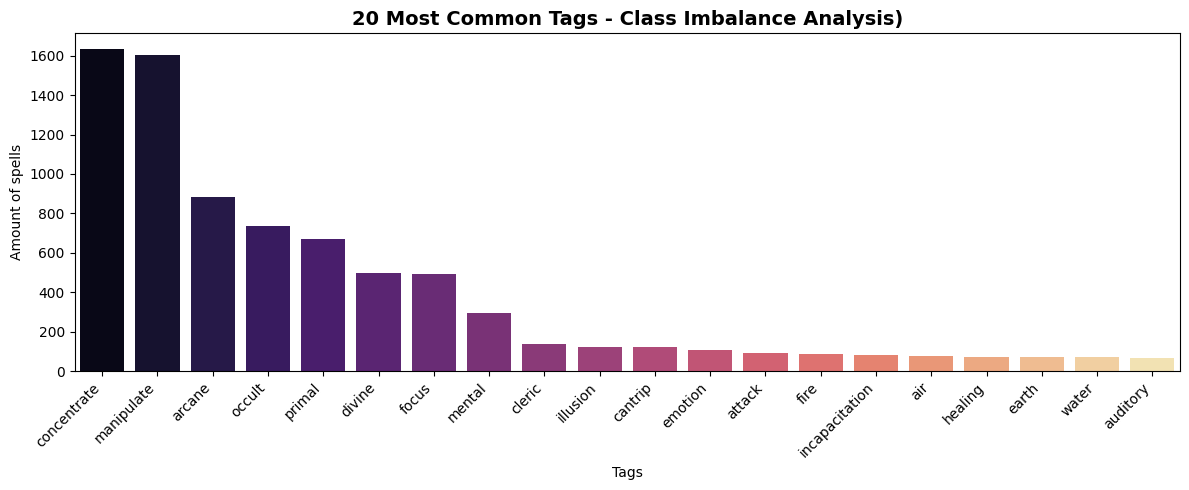

In [3]:
plt.figure(figsize=(12, 5))
all_tags_series = df.explode('tags')['tags'].dropna()
top_tags = all_tags_series.value_counts().head(20)

sns.barplot(x=top_tags.index, y=top_tags.values, palette='magma')
plt.title('20 Most Common Tags - Class Imbalance Analysis)', fontsize=14, fontweight='bold')
plt.xlabel('Tags')
plt.ylabel('Amount of spells')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Reading the graph:** Taller bars represent tags that occur in more spells.

**What we see:** `concentrate` and `manipulate` occur much more often than the other tags.

**Conclusion / action:** The tags are imbalanced, so use tag frequencies carefully or apply balancing when training a model.

### Average description length by level

This process compares the average number of words in spells at each level to see whether higher-level spells are more detailed.

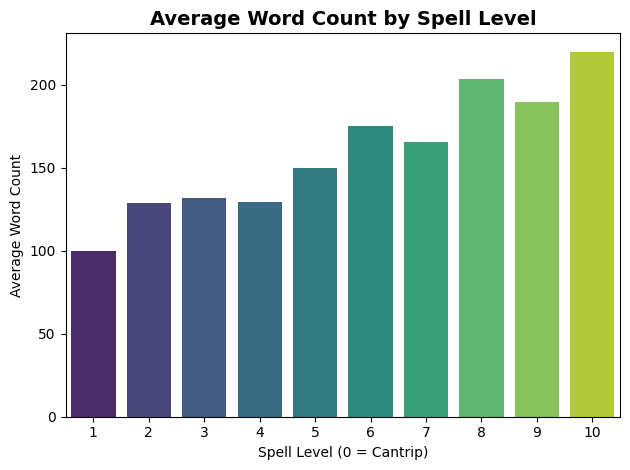

In [4]:
sns.barplot(data=df, x='level', y='word_count', estimator=np.mean, errorbar=None, palette='viridis')
plt.title('Average Word Count by Spell Level', fontsize=14, fontweight='bold')
plt.xlabel('Spell Level (0 = Cantrip)')
plt.ylabel('Average Word Count')
plt.tight_layout()
plt.show()

**Reading the graph:** Each bar shows the mean description length for one spell level.

**What we see:** Higher-level spells generally have longer descriptions.

**Conclusion / action:** Word count can be a useful feature, but it should not be used alone to predict spell level.

### Tags per spell

This process counts how many tags each spell has and shows the typical amount of metadata attached to a spell.

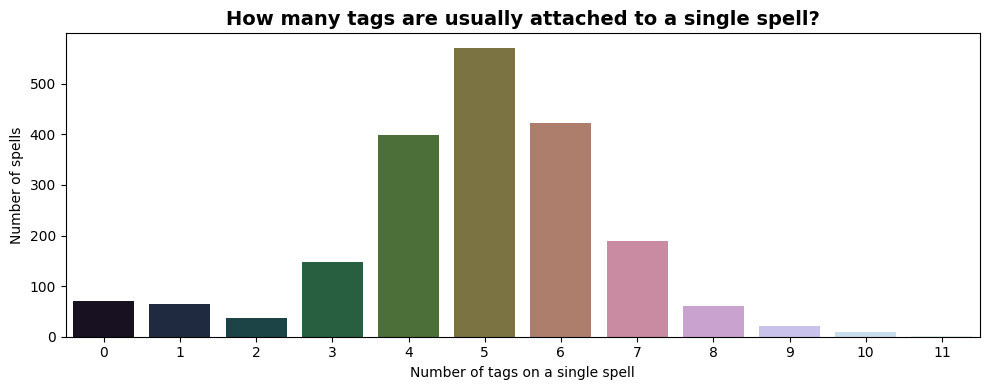

In [5]:
plt.figure(figsize=(10, 4))
sns.countplot(data=df, x='tag_count', palette='cubehelix')
plt.title('How many tags are usually attached to a single spell?', fontsize=14, fontweight='bold')
plt.xlabel('Number of tags on a single spell')
plt.ylabel('Number of spells')
plt.tight_layout()
plt.show()

**Reading the graph:** Higher bars mean that more spells contain that number of tags.

**What we see:** Most spells have about 4 to 6 tags, with 5 tags being the most common.

**Conclusion / action:** Tag count is fairly consistent and can be used as a simple metadata feature.

### Tag co-occurrence

This process measures how often the most common tags appear together in the same spell.

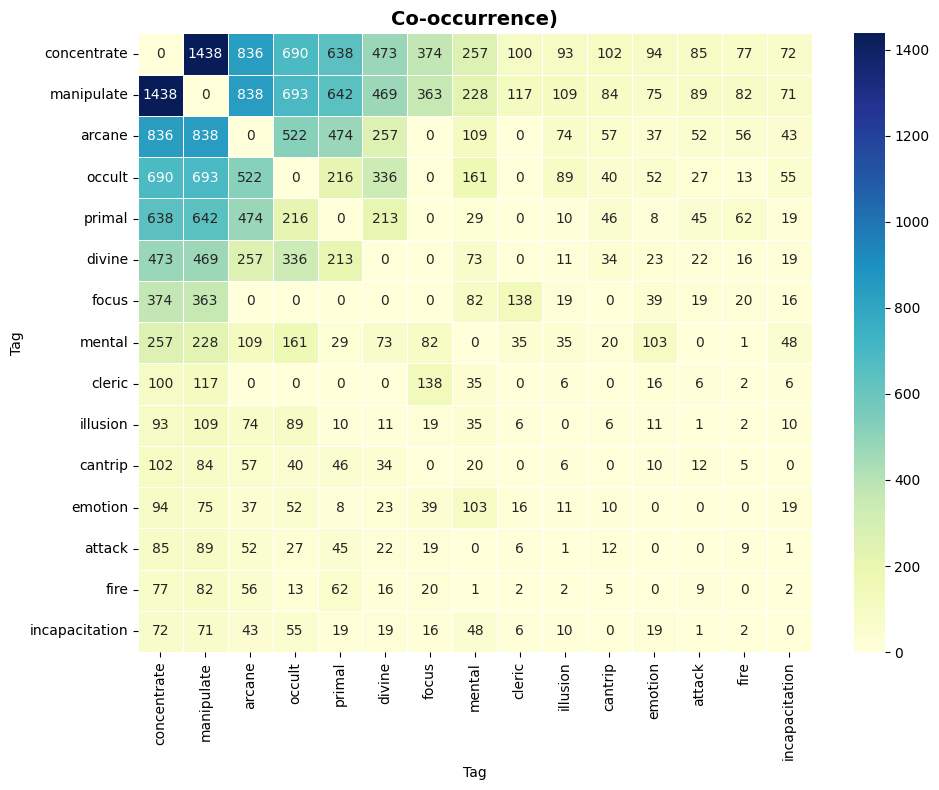

In [6]:
#excluded_tags = {'arcane', 'occult', 'primal', 'divine'}
#filtered_tags = df['tags'].apply(
#    lambda tags: [tag for tag in (tags or []) if tag.casefold() not in excluded_tags]
#)

#mlb = MultiLabelBinarizer()
#tags_encoded = mlb.fit_transform(filtered_tags)

mlb = MultiLabelBinarizer()
tags_encoded = mlb.fit_transform(df['tags'])
tags_df = pd.DataFrame(tags_encoded, columns=mlb.classes_)

top_15_tags = tags_df.sum().nlargest(15).index
tags_top15_df = tags_df[top_15_tags]

co_matrix = tags_top15_df.T.dot(tags_top15_df)

# Remove self-co-occurrence values without modifying a read-only array
co_matrix = co_matrix.mask(
    np.eye(co_matrix.shape[0], dtype=bool),
    0
)

plt.figure(figsize=(10, 8))
sns.heatmap(co_matrix, annot=True, fmt='d', cmap='YlGnBu', linewidths=.5)
plt.title('Co-occurrence)', fontsize=14, fontweight='bold')
plt.xlabel('Tag')
plt.ylabel('Tag')
plt.tight_layout()
plt.show()

**Reading the graph:** Darker or larger values indicate tag pairs that occur together more often.

**What we see:** `concentrate` and `manipulate` have the strongest co-occurrence.

**Conclusion / action:** Tags are related rather than independent, so combinations of tags may improve analysis.

### Most common words

This process counts important words in spell descriptions after removing common English stop words, helping identify possible text features.

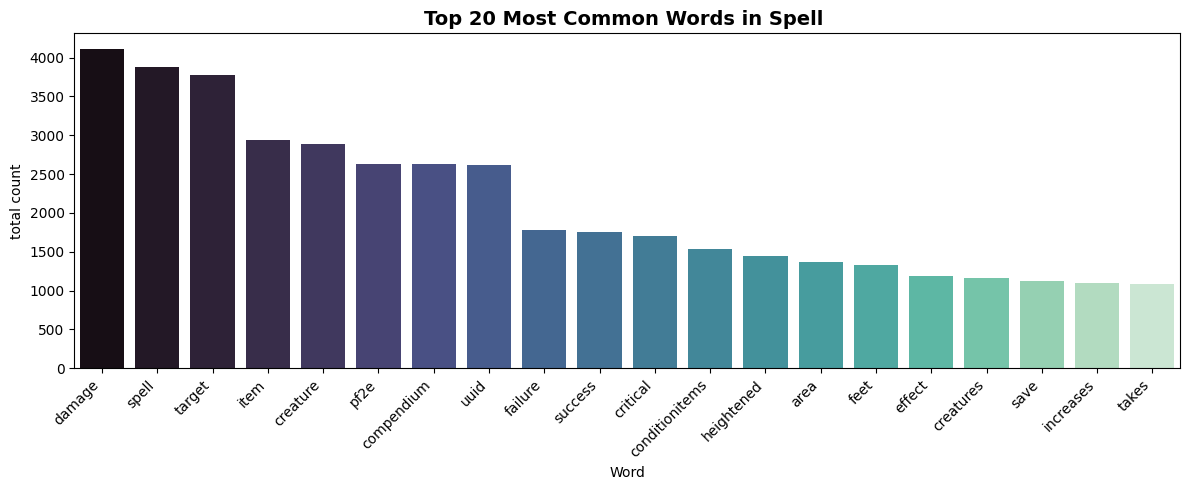

In [7]:
plt.figure(figsize=(12, 5))
# CountVectorizer deleting of the unnecessary words and limiting the number of features to 20 for better visualization
vectorizer = CountVectorizer(stop_words='english', max_features=20)
word_counts = vectorizer.fit_transform(df['clean_desc'])

# collect the words and their counts into a DataFrame for easier plotting
words_df = pd.DataFrame({
    'Word': vectorizer.get_feature_names_out(), 
    'Count': word_counts.toarray().sum(axis=0)
}).sort_values(by='Count', ascending=False)

sns.barplot(data=words_df, x='Word', y='Count', palette='mako')
plt.title('Top 20 Most Common Words in Spell ', fontsize=14, fontweight='bold')
plt.xlabel('Word')
plt.ylabel('total count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Reading the graph:** The bars show which meaningful words appear most often in spell descriptions.

**What we see:** Words such as `damage`, `target`, and `creature` are especially common.

**Conclusion / action:** These words describe general spell structure, so remove or reduce their weight if more specific features are needed.

### Less dominant common words

This process focuses on frequent words with fewer than 2,000 occurrences so less dominant vocabulary remains visible.

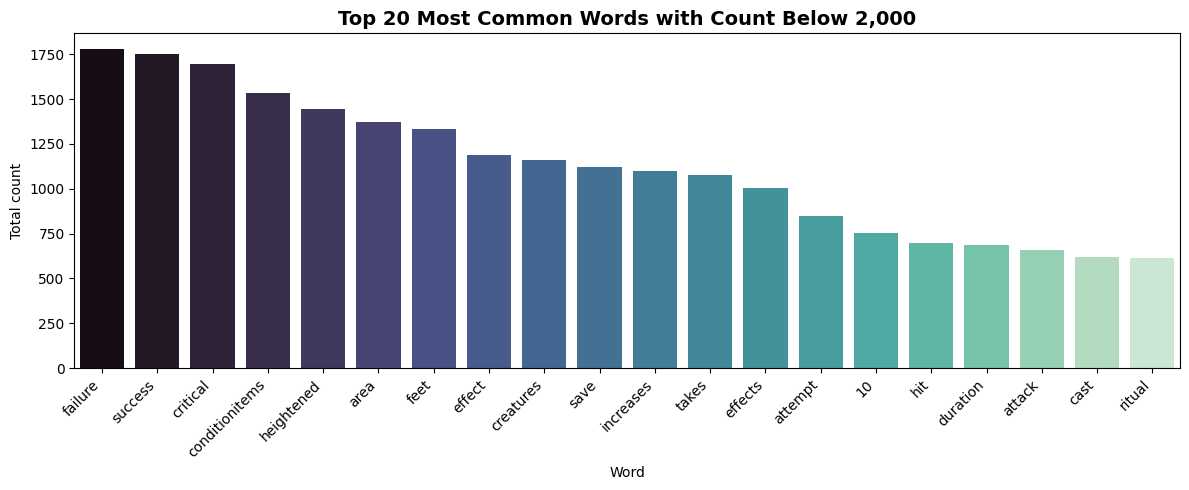

In [9]:
# Count all words, then keep only those with a total count below 2,000
filtered_vectorizer = CountVectorizer(stop_words='english')
filtered_word_counts = filtered_vectorizer.fit_transform(df['clean_desc'])

filtered_words_df = pd.DataFrame({
    'Word': filtered_vectorizer.get_feature_names_out(),
    'Count': filtered_word_counts.toarray().sum(axis=0)
})
filtered_words_df = (
    filtered_words_df[filtered_words_df['Count'] < 2000]
    .sort_values(by='Count', ascending=False)
    .head(20)
)

plt.figure(figsize=(12, 5))
sns.barplot(data=filtered_words_df, x='Word', y='Count', palette='mako')
plt.title('Top 20 Most Common Words with Count Below 2,000', fontsize=14, fontweight='bold')
plt.xlabel('Word')
plt.ylabel('Total count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

**Reading the graph:** This view highlights common words that are frequent but not overwhelmingly dominant.

**What we see:** `failure`, `success`, and `critical` are common outcome-related words.

**Conclusion / action:** These terms may help identify spell effects, so keep them as candidate text features.